In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import matplotlib.pyplot as plt

print("Imports ready")


Imports ready


In [3]:
train_file = 'C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt'  
test_file = 'C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt'    
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
    "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]

# Load CSVs
train_df = pd.read_csv(train_file, names=columns)
test_df = pd.read_csv(test_file, names=columns)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)
train_df.head()


Train shape: (125973, 42) Test shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,tcp,ftp_data,SF,491,0,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
0,udp,other,SF,146,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
0,tcp,private,S0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
0,tcp,http,SF,232,8153,0,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
0,tcp,http,SF,199,420,0,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Class distribution after aggregation (train):
outcome
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
Other                 33
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
Name: count, dtype: int64

Class distribution after aggregation (test):
outcome
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap    

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\

                 precision    recall  f1-score   support

          Other       0.40      0.15      0.22        27
        apache2       0.00      0.00      0.00       737
           back       0.12      0.14      0.13       359
buffer_overflow       0.00      0.00      0.00        20
   guess_passwd       1.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.69      0.97      0.81       141
           land       1.00      1.00      1.00         7
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
          named       0.00      0.00      0.00        17
        neptune       0.93      0.99      0.96      4657
           nmap       0.45      0.99      0.62        73
         normal       0.63      0.93      0.75      9711
            pod       0.71      0.85      0.78        41
      portsweep       0.69    

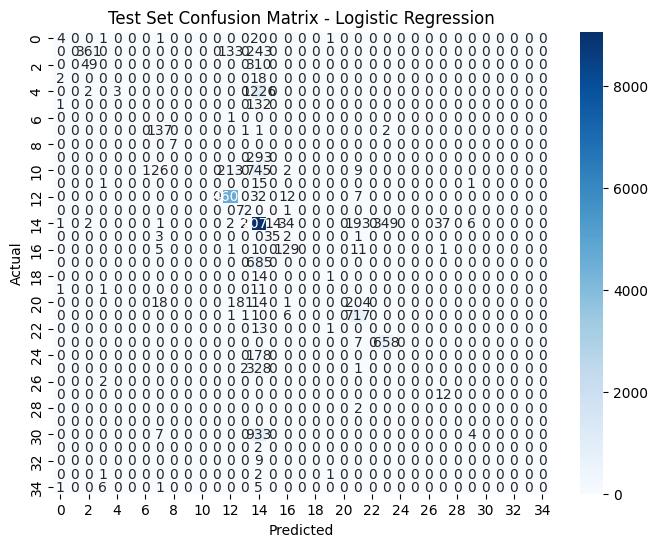

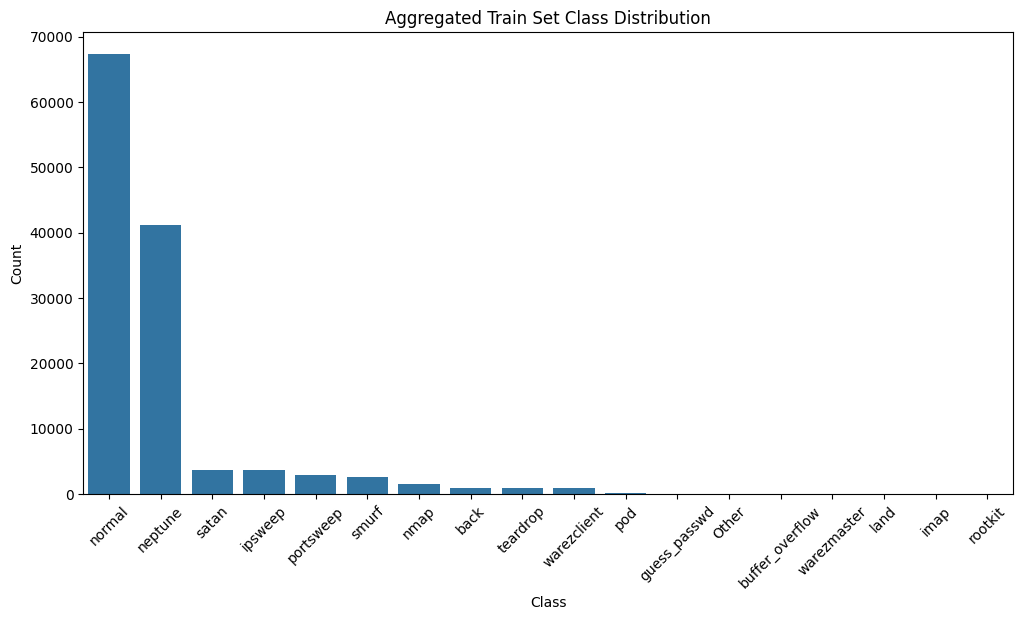

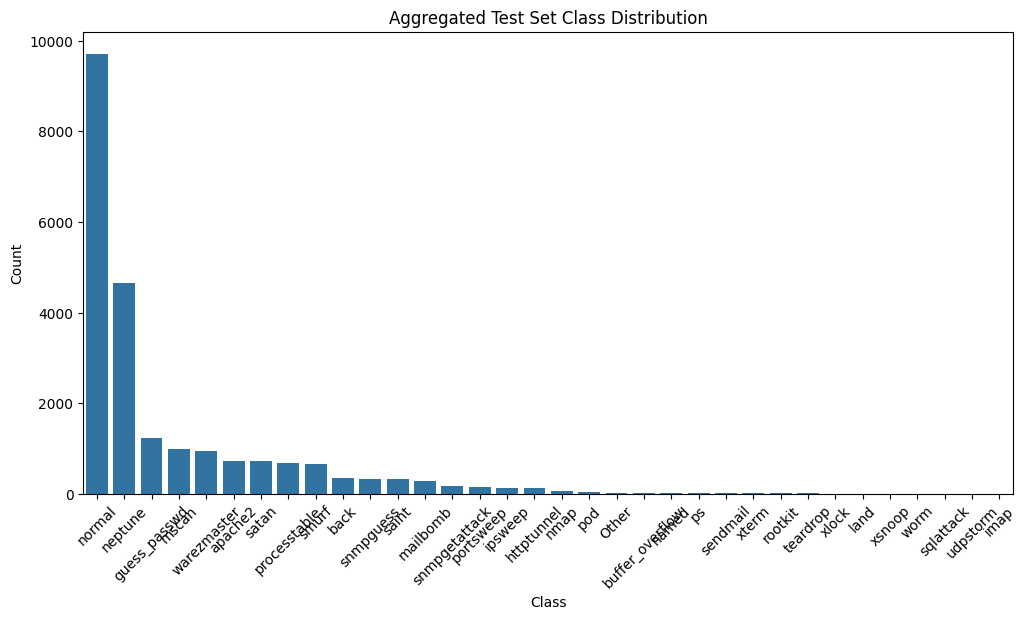

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Column names for NSL-KDD
cols = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
        'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
        'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
        'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
        'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
        'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
        'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
        'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome', 'level']

# Load dataset paths
train_path = 'C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt'
test_path = 'C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt'

# Load data
train_data = pd.read_csv(train_path, names=cols)
test_data = pd.read_csv(test_path, names=cols)

# Prepare features and labels
X_train = train_data.drop(['outcome', 'level'], axis=1)
y_train = train_data['outcome']
X_test = test_data.drop(['outcome', 'level'], axis=1)
y_test = test_data['outcome']

# One-hot encode categorical columns
X_train = pd.get_dummies(X_train, columns=['protocol_type', 'service', 'flag'])
X_test = pd.get_dummies(X_test, columns=['protocol_type', 'service', 'flag'])

# Align test features to train features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aggregate rare classes into 'Other'
min_class_samples = 10
value_counts = y_train.value_counts()
rare_classes = value_counts[value_counts < min_class_samples].index
y_train_agg = y_train.apply(lambda x: 'Other' if x in rare_classes else x)
y_test_agg = y_test.apply(lambda x: 'Other' if x in rare_classes else x)

print("Class distribution after aggregation (train):")
print(y_train_agg.value_counts())
print("\nClass distribution after aggregation (test):")
print(y_test_agg.value_counts())

# Dimensionality reduction with PCA
pca = PCA(n_components=15, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train_agg)

# Sample to reduce memory if needed
sample_size = 30000
if len(y_train_resampled) > sample_size:
    X_train_resampled_sample = X_train_resampled[:sample_size]
    y_train_resampled_sample = y_train_resampled[:sample_size]
else:
    X_train_resampled_sample = X_train_resampled
    y_train_resampled_sample = y_train_resampled

# Train Logistic Regression (memory efficient)
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_resampled_sample, y_train_resampled_sample)

# Predictions
y_train_pred = model.predict(X_train_pca)
y_test_pred = model.predict(X_test_pca)

# Accuracy scores
train_acc = accuracy_score(y_train_agg, y_train_pred)
test_acc = accuracy_score(y_test_agg, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("Test Classification Report:")
print(classification_report(y_test_agg, y_test_pred))


# Visualization functions
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()

def plot_class_distribution(y, title="Class Distribution"):
    counts = y.value_counts()
    plt.figure(figsize=(12,6))
    sns.barplot(x=counts.index, y=counts.values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.ylabel('Count')
    plt.xlabel('Class')
    plt.show()

# Plotting
plot_conf_matrix(y_test_agg, y_test_pred, "Test Set Confusion Matrix - Logistic Regression")
plot_class_distribution(y_train_agg, "Aggregated Train Set Class Distribution")
plot_class_distribution(y_test_agg, "Aggregated Test Set Class Distribution")
